In [4]:
import pandas as pd
import json
import gzip
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [5]:
interactions = []
with gzip.open('../data/raw/goodreads_interactions_children.json.gz', 'rt') as f:
    for i, line in enumerate(f):
        if i >= 100000:  # 100k rows is enough to start
            break
        interactions.append(json.loads(line))

df_interactions = pd.DataFrame(interactions)
print(df_interactions.shape)
print(df_interactions.columns.tolist())
df_interactions.head()

(100000, 10)
['user_id', 'book_id', 'review_id', 'is_read', 'rating', 'review_text_incomplete', 'date_added', 'date_updated', 'read_at', 'started_at']


,user_id,book_id,review_id,is_read,rating,review_text_incomplete,date_added,date_updated,read_at,started_at
0,8842281e1d1347389f2ab93d60773d4d,10893214,5d0e4e8825c68740703f65a18813fc93,False,0,,Fri Feb 24 09:00:30 -0800 2017,Fri Feb 24 09:00:30 -0800 2017,,
1,8842281e1d1347389f2ab93d60773d4d,33282947,f171a68daa8092d8aea3dccc2e025a81,False,0,,Fri Feb 10 10:47:53 -0800 2017,Fri Feb 10 10:48:21 -0800 2017,,
2,8842281e1d1347389f2ab93d60773d4d,11387515,2fd3cd1acb30b099c135e358669639da,False,0,,Thu Jan 26 13:35:10 -0800 2017,Thu Jan 26 13:35:10 -0800 2017,,
3,8842281e1d1347389f2ab93d60773d4d,24396144,d210e41fcc7e6dcd6ae896844a38a024,False,0,,Thu Dec 15 15:37:54 -0800 2016,Thu Dec 15 15:37:55 -0800 2016,,
4,8842281e1d1347389f2ab93d60773d4d,20484662,a99f9fa4ec4fd94cc2419c78af2086a8,False,0,,Sun May 15 14:49:50 -0700 2016,Sun May 15 14:49:51 -0700 2016,,


In [7]:
print(f"Total interactions: {len(df_interactions):,}")
print(f"Ratings of 0 (no rating given): {(df_interactions['rating'] == 0).sum():,}")
print(f"Explicit ratings (1-5): {(df_interactions['rating'] > 0).sum():,}")
print(f"\nRating value counts:")
print(df_interactions['rating'].value_counts().sort_index())

df_rated = df_interactions[df_interactions['rating'] > 0].copy()
print(f"Kept {len(df_rated):,} explicit ratings out of {len(df_interactions):,} total ({len(df_rated)/len(df_interactions)*100:.1f}%)")

Total interactions: 100,000
Ratings of 0 (no rating given): 33,371
Explicit ratings (1-5): 66,629

Rating value counts:
rating
0    33371
1      590
2     2935
3    15714
4    23457
5    23933
Name: count, dtype: int64
Kept 66,629 explicit ratings out of 100,000 total (66.6%)


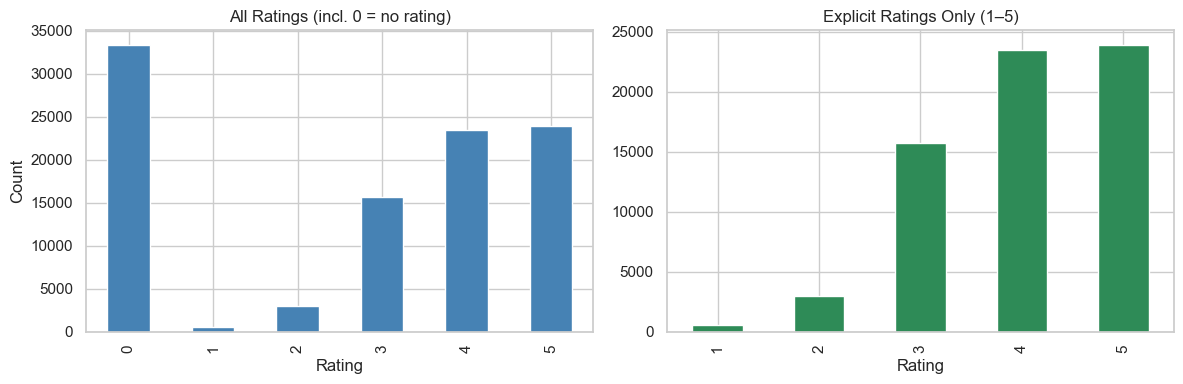

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# All ratings including 0
df_interactions['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title('All Ratings (incl. 0 = no rating)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Explicit only
df_rated['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='seagreen'
)
axes[1].set_title('Explicit Ratings Only (1–5)')
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()

Total unique users: 3,479
Ratings per user — mean: 19.2, median: 5
Users with only 1 rating: 621
Users with 5+ ratings:    1,929
Users with 20+ ratings:   745


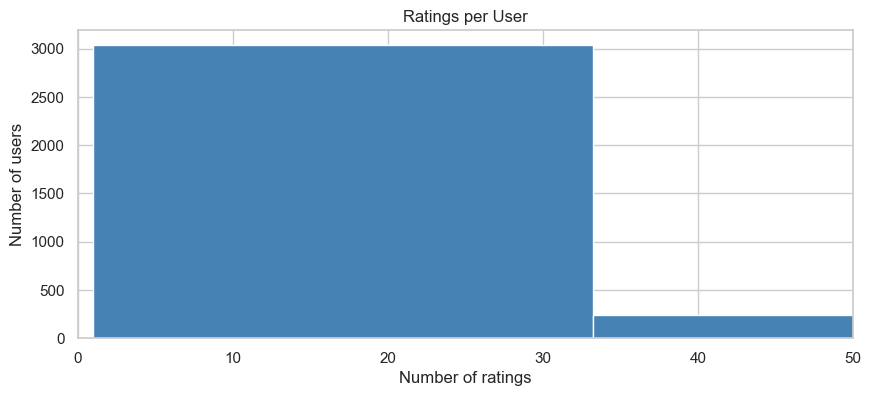

In [9]:
user_activity = df_rated.groupby('user_id')['rating'].count()

print(f"Total unique users: {user_activity.shape[0]:,}")
print(f"Ratings per user — mean: {user_activity.mean():.1f}, median: {user_activity.median():.0f}")
print(f"Users with only 1 rating: {(user_activity == 1).sum():,}")
print(f"Users with 5+ ratings:    {(user_activity >= 5).sum():,}")
print(f"Users with 20+ ratings:   {(user_activity >= 20).sum():,}")

user_activity.hist(bins=50, figsize=(10, 4), color='steelblue', edgecolor='white')
plt.title('Ratings per User')
plt.xlabel('Number of ratings')
plt.ylabel('Number of users')
plt.xlim(0, 50)  # cap x axis so the long tail doesn't squash the chart
plt.show()

Total unique books: 18,304
Ratings per book — mean: 3.6, median: 1
Books with only 1 rating:  12,031
Books with 10+ ratings:    828


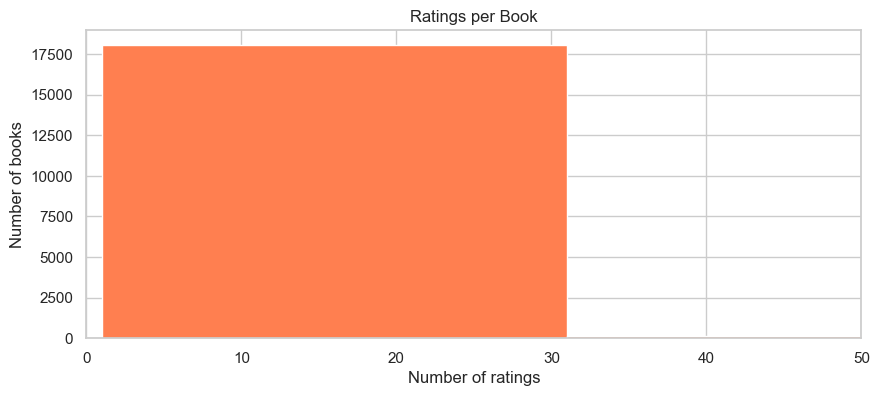

In [10]:
book_activity = df_rated.groupby('book_id')['rating'].count()

print(f"Total unique books: {book_activity.shape[0]:,}")
print(f"Ratings per book — mean: {book_activity.mean():.1f}, median: {book_activity.median():.0f}")
print(f"Books with only 1 rating:  {(book_activity == 1).sum():,}")
print(f"Books with 10+ ratings:    {(book_activity >= 10).sum():,}")

book_activity.hist(bins=50, figsize=(10, 4), color='coral', edgecolor='white')
plt.title('Ratings per Book')
plt.xlabel('Number of ratings')
plt.ylabel('Number of books')
plt.xlim(0, 50)
plt.show()

In [11]:
# Cell 8 — Sparsity calculation
total_possible = 3479 * 18304
actual_ratings = len(df_rated)
sparsity = 1 - (actual_ratings / total_possible)
print(f"Matrix sparsity: {sparsity*100:.2f}%")

Matrix sparsity: 99.90%


In [12]:
min_user_ratings = 5
min_book_ratings = 5

active_users = user_activity[user_activity >= min_user_ratings].index
popular_books = book_activity[book_activity >= min_book_ratings].index

df_filtered = df_rated[
    df_rated['user_id'].isin(active_users) &
    df_rated['book_id'].isin(popular_books)
].copy()

print(f"Before filtering: {len(df_rated):,} ratings, {df_rated['user_id'].nunique():,} users, {df_rated['book_id'].nunique():,} books")
print(f"After filtering:  {len(df_filtered):,} ratings, {df_filtered['user_id'].nunique():,} users, {df_filtered['book_id'].nunique():,} books")

# Recalculate sparsity on filtered set
total_possible_filtered = df_filtered['user_id'].nunique() * df_filtered['book_id'].nunique()
sparsity_filtered = 1 - (len(df_filtered) / total_possible_filtered)
print(f"Filtered matrix sparsity: {sparsity_filtered*100:.2f}%")

Before filtering: 66,629 ratings, 3,479 users, 18,304 books
After filtering:  40,879 ratings, 1,911 users, 1,894 books
Filtered matrix sparsity: 98.87%


In [13]:
df_filtered.to_csv('../data/processed/interactions_filtered.csv', index=False)
print("Saved to data/processed/interactions_filtered.csv")

Saved to data/processed/interactions_filtered.csv
